
# CO₂ Emissions Analysis

This notebook contains the EDA, correlation analysis, and linear regression baselines for the `FuelConsumptionCo2.csv` dataset.

**Files created:**
- CO2_analysis_report.pdf (polished PDF report)





## Summary & Key Findings

- Dataset size: **1067 rows × 13 columns**.  
- Mean CO2EMISSIONS: **256.23 g/km**.  

### Top correlated features (with CO₂)
- **FUELCONSUMPTION_COMB_MPG**: correlation -0.906
- **FUELCONSUMPTION_CITY**: correlation 0.898
- **FUELCONSUMPTION_COMB**: correlation 0.892
- **ENGINESIZE**: correlation 0.874
- **FUELCONSUMPTION_HWY**: correlation 0.862
- **CYLINDERS**: correlation 0.850

### Modeling summary
- Linear regression (EngineSize) R² ≈ 0.76; RMSE ≈ 31 g/km.
- Linear regression (EngineSize + FuelConsumption_Comb) R² ≈ 0.87; RMSE ≈ 23 g/km.

The following cells reproduce the core analysis and plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


                          CO2EMISSIONS
CO2EMISSIONS                  1.000000
FUELCONSUMPTION_CITY          0.898039
FUELCONSUMPTION_COMB          0.892129
ENGINESIZE                    0.874154
FUELCONSUMPTION_HWY           0.861748
CYLINDERS                     0.849685
FUELCONSUMPTION_COMB_MPG     -0.906394
MODELYEAR                          NaN


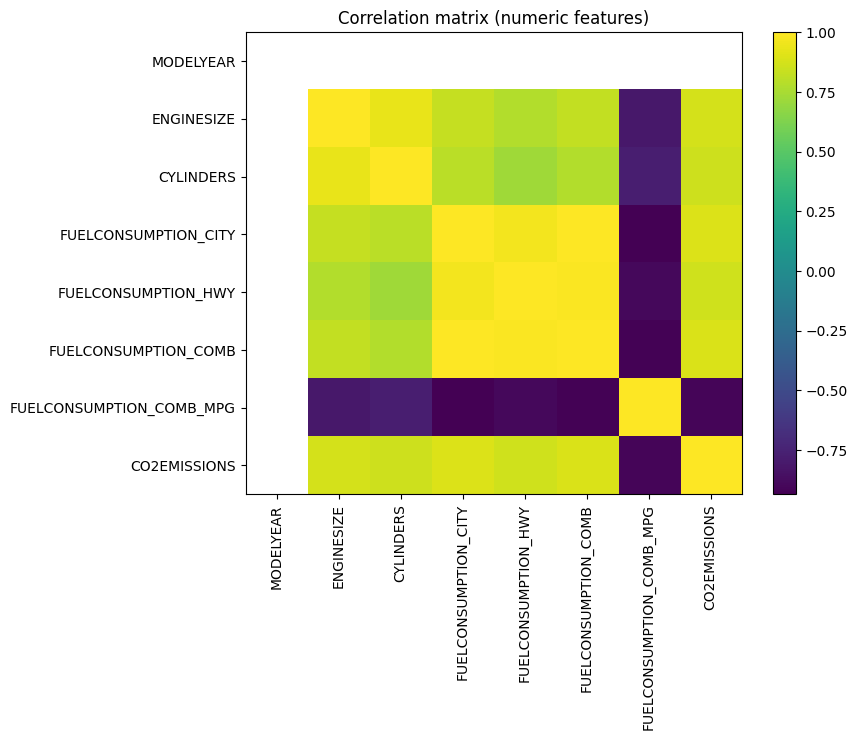

In [2]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()
print(corr[['CO2EMISSIONS']].sort_values(by='CO2EMISSIONS', ascending=False))

plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation matrix (numeric features)')
plt.show()

slope: 38.992978724434074 intercept: 126.28970217408721
RMSE: 985.9381692274999
R2: 0.7615595731934373


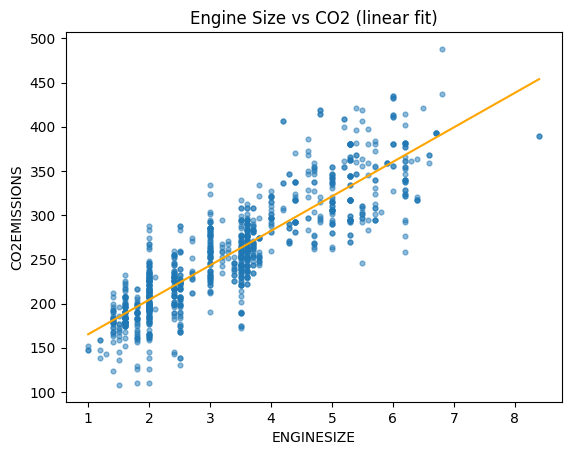

In [4]:
# Linear regression baseline (EngineSize -> CO2)
engine_col = 'ENGINESIZE'
co2_col = 'CO2EMISSIONS'
X = df[[engine_col]].values
y = df[co2_col].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('slope:', lr.coef_[0], 'intercept:', lr.intercept_)
print('RMSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

plt.scatter(X, y, s=12, alpha=0.5)
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
plt.plot(x_grid, lr.predict(x_grid), color='orange')
plt.xlabel(engine_col)
plt.ylabel(co2_col)
plt.title('Engine Size vs CO2 (linear fit)')
plt.show()

Features used: ['ENGINESIZE', 'FUELCONSUMPTION_COMB']
Coefficients: {'ENGINESIZE': 19.592827232761053, 'FUELCONSUMPTION_COMB': 9.618439340589193}
RMSE: 543.5778099752669
R2: 0.8685405139405123


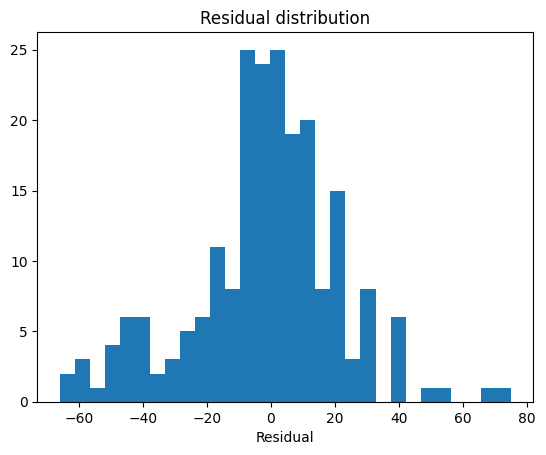

In [6]:
# Multiple linear regression (EngineSize + FuelConsumption_comb)
features = ['ENGINESIZE', 'FUELCONSUMPTION_COMB']
print('Features used:', features)
X_multi = df[features].values
y = df['CO2EMISSIONS'].values
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)
lr_multi = LinearRegression().fit(X_train, y_train)
y_pred_m = lr_multi.predict(X_test)
print('Coefficients:', dict(zip(features, lr_multi.coef_)))
print('RMSE:', mean_squared_error(y_test, y_pred_m))
print('R2:', r2_score(y_test, y_pred_m))

# residual histogram
import matplotlib.pyplot as plt
residuals = y_test - y_pred_m
plt.hist(residuals, bins=30)
plt.xlabel('Residual')
plt.title('Residual distribution')
plt.show()